# ARIMA Forecasting per Produk

Notebook ini melakukan forecasting menggunakan model ARIMA untuk **setiap produk** secara individual.

## 1. Import Library

In [2]:
%pip install scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Load Dataset

In [3]:
# Load the dataset
file_path = 'Dataset_Forecasting_ARIMA_Lengkap.xlsx'
dataset = pd.read_excel(file_path)

print("Dataset Info:")
print(dataset.head())
print(f"\nJumlah data: {len(dataset)}")
print(f"Kolom: {dataset.columns.tolist()}")

Dataset Info:
                  Date  GB-BB-10  GB-BB-30  GB-TP-CC  GB-CNF-30  GB-CNF-10  \
0  2025-01-01 00:00:00       0.0       0.0       0.0        0.0        0.0   
1  2025-01-02 00:00:00       0.0       1.0       0.0        3.0       14.0   
2  2025-01-03 00:00:00       1.0       0.0       0.0       18.0       45.0   
3  2025-01-04 00:00:00       0.0       0.0       0.0        8.0        4.0   
4  2025-01-05 00:00:00       0.0       0.0       0.0        0.0        0.0   

   GB-CNF-100  GB-CNF-250  GB-DS-30  GB-DS-10  ...  GB-LDR-250  GB-MYB-30  \
0         0.0         0.0       0.0       0.0  ...         0.0        0.0   
1         0.0         0.0       2.0       9.0  ...         0.0        0.0   
2         0.0         0.0      13.0      14.0  ...         0.0        0.0   
3         0.0         0.0       1.0       0.0  ...         0.0        0.0   
4         0.0         0.0       0.0       0.0  ...         0.0        0.0   

   GB-MYB-10  GB-MYB-100  GB-TP-NB  GB-TC-30  GB-TC-10

## 3. Preprocessing Data

In [4]:
# Remove non-date rows (summary rows like 'pemakaian maksimum', 'pemakaian rata rata', 'lead time')
dataset = dataset[pd.to_datetime(dataset['Date'], errors='coerce').notna()].copy()

# Convert 'Date' column to datetime format and set as index
dataset['Date'] = pd.to_datetime(dataset['Date'])
dataset.set_index('Date', inplace=True)

# Identifikasi kolom produk (exclude Total_Sales)
product_columns = [col for col in dataset.columns if col != 'Total_Sales']

print(f"Jumlah produk yang akan diprediksi: {len(product_columns)}")
print(f"\nDaftar produk: {', '.join(product_columns)}")

Jumlah produk yang akan diprediksi: 31

Daftar produk: GB-BB-10, GB-BB-30, GB-TP-CC, GB-CNF-30, GB-CNF-10, GB-CNF-100, GB-CNF-250, GB-DS-30, GB-DS-10, GB-DS-100, GB-DS-250, GB-GF-30, GB-GF-10, GB-GF-250, GB-IB-30, GB-IB-10, GB-IB-100, GB-JOY-30, GB-JOY-10, GB-JOY-100, GB-LDR-30, GB-LDR-10, GB-LDR-250, GB-MYB-30, GB-MYB-10, GB-MYB-100, GB-TP-NB, GB-TC-30, GB-TC-10, GB-TC-250, GB-TP-TV


## 4. Fungsi Helper untuk ARIMA Forecasting

In [5]:
def arima_forecast_product(
    data,
    product_name,
    train_ratio=0.9,
    base_orders=None,
    extended_orders=None,
    use_extended=False,
    fill_method='ffill'
    ):
    """
    Melakukan ARIMA forecasting untuk satu produk dengan pemilihan order adaptif.
    
    Strategy:
    - Base tuning: kandidat order ringkas untuk semua produk
    - Extended tuning: kandidat order lebih luas untuk produk yang MAE-nya masih tinggi
    - Low-MAE products akan disederhanakan order-nya di tahap segment tuning
    """
    try:
        # Pastikan index date harian lengkap
        complete_date_range = pd.date_range(start=data.index.min(), end=data.index.max(), freq='D')
        data_reindexed = data.reindex(complete_date_range)
        
        # Isi missing value
        if fill_method == 'ffill':
            data_reindexed = data_reindexed.ffill().fillna(0)
        else:
            data_reindexed = data_reindexed.fillna(0)
        
        # ADF Test untuk stationarity
        adf_result = adfuller(data_reindexed)
        is_stationary = adf_result[1] < 0.05
        d_pref = 0 if is_stationary else 1
        
        # Kandidat order default
        default_base_orders = [
            (1, d_pref, 1),
            (2, d_pref, 1),
            (1, d_pref, 2),
            (2, d_pref, 2),
            (3, d_pref, 1),
            (1, 0, 1),
            (1, 1, 1),
            (0, 1, 1),
        ]
        
        default_extended_orders = default_base_orders + [
            (3, d_pref, 2),
            (2, d_pref, 3),
            (3, d_pref, 3),
            (4, d_pref, 1),
            (4, d_pref, 2),
            (2, 1, 3),
            (3, 1, 2),
            (3, 1, 3),
            (2, 0, 3),
            (3, 0, 2),
        ]
        
        # Hilangkan duplikasi order sambil pertahankan urutan
        def unique_orders(orders):
            seen = set()
            unique = []
            for order in orders:
                if order not in seen:
                    seen.add(order)
                    unique.append(order)
            return unique
        
        default_base_orders = unique_orders(default_base_orders)
        default_extended_orders = unique_orders(default_extended_orders)
        
        selected_base_orders = unique_orders(base_orders) if base_orders else default_base_orders
        selected_extended_orders = unique_orders(extended_orders) if extended_orders else default_extended_orders
        candidate_orders = selected_extended_orders if use_extended else selected_base_orders
        
        # Split data
        train_size = int(len(data_reindexed) * train_ratio)
        train_data = data_reindexed[:train_size]
        test_data = data_reindexed[train_size:]
        
        if len(train_data) < 10 or len(test_data) < 2:
            raise ValueError('Data train/test terlalu sedikit untuk ARIMA')
        
        # Evaluasi semua kandidat order
        order_metrics = []
        best_model = None
        best_order = None
        best_forecast = None
        best_mae = np.inf
        
        for order in candidate_orders:
            try:
                model = ARIMA(train_data, order=order)
                fitted_model = model.fit()
                forecast = fitted_model.forecast(steps=len(test_data))
                forecast = np.maximum(forecast, 0)
                
                mae = mean_absolute_error(test_data, forecast)
                rmse = np.sqrt(mean_squared_error(test_data, forecast))
                mape = np.mean(np.abs((test_data - forecast) / (test_data + 1))) * 100
                
                order_metrics.append({
                    'Order': order,
                    'MAE': float(mae),
                    'RMSE': float(rmse),
                    'MAPE (%)': float(mape),
                    'AIC': float(fitted_model.aic)
                })
                
                if mae < best_mae:
                    best_mae = mae
                    best_model = fitted_model
                    best_order = order
                    best_forecast = forecast
            except Exception:
                # Skip kandidat yang gagal fit
                continue
        
        if best_model is None:
            raise ValueError('Semua kandidat order ARIMA gagal di-fit')
        
        order_metrics_df = pd.DataFrame(order_metrics).sort_values('MAE').reset_index(drop=True)
        scope_label = 'extended' if use_extended else 'base'
        
        return {
            'product': product_name,
            'success': True,
            'train_data': train_data,
            'test_data': test_data,
            'forecast': best_forecast,
            'mae': float(best_mae),
            'rmse': float(np.sqrt(mean_squared_error(test_data, best_forecast))),
            'mape': float(np.mean(np.abs((test_data - best_forecast) / (test_data + 1))) * 100),
            'is_stationary': is_stationary,
            'adf_pvalue': float(adf_result[1]),
            'used_order': best_order,
            'order_metrics': order_metrics_df,
            'search_scope': scope_label,
            'model_summary': best_model.summary()
        }
    except Exception as e:
        print(f"Error forecasting {product_name}: {str(e)}")
        return {
            'product': product_name,
            'success': False,
            'error': str(e)
        }

print("✅ Fungsi helper ARIMA adaptif telah dibuat")

✅ Fungsi helper ARIMA adaptif telah dibuat


## 5. Jalankan ARIMA Forecasting untuk Semua Produk

In [6]:
# Dictionary untuk menyimpan hasil forecasting
forecast_results = {}

print("Memulai forecasting tahap 1 (base tuning) untuk semua produk...")
print("=" * 90)

for i, product in enumerate(product_columns, 1):
    print(f"[{i}/{len(product_columns)}] Base tuning: {product}...", end=" ")
    
    result = arima_forecast_product(
        data=dataset[product],
        product_name=product,
        train_ratio=0.9,
        use_extended=False
    )
    
    forecast_results[product] = result
    
    if result['success']:
        order_str = str(result.get('used_order'))
        print(f"✅ MAE: {result['mae']:.2f} | Order: {order_str}")
    else:
        print("❌ Error")

print("=" * 90)
print("Segmentasi MAE dan penyesuaian model (tahap 2)...")

# Ambil hasil sukses untuk menentukan segmentasi MAE
successful_items = {p: r for p, r in forecast_results.items() if r.get('success')}

if successful_items:
    mae_series = pd.Series({p: r['mae'] for p, r in successful_items.items()})
    q_low = mae_series.quantile(0.33)
    q_high = mae_series.quantile(0.66)
    
    print(f"Batas MAE rendah <= {q_low:.2f}")
    print(f"Batas MAE menengah <= {q_high:.2f}")
    
    retuned_count = 0
    simplified_count = 0
    
    for product, old_result in list(successful_items.items()):
        old_mae = old_result['mae']
        old_order = old_result['used_order']
        
        # 1) Produk MAE rendah: pilih model lebih sederhana bila performanya mirip (parsimonious)
        if old_mae <= q_low:
            metrics_df = old_result.get('order_metrics', pd.DataFrame())
            if not metrics_df.empty:
                tolerance = old_mae * 1.05  # toleransi 5% dari MAE terbaik
                near_best = metrics_df[metrics_df['MAE'] <= tolerance].copy()
                if not near_best.empty:
                    near_best['complexity'] = near_best['Order'].apply(lambda x: sum(x))
                    simple_choice = near_best.sort_values(['complexity', 'MAE']).iloc[0]['Order']
                    
                    if simple_choice != old_order:
                        simplified_result = arima_forecast_product(
                            data=dataset[product],
                            product_name=product,
                            train_ratio=0.9,
                            base_orders=[simple_choice],
                            use_extended=False
                        )
                        if simplified_result['success']:
                            forecast_results[product] = simplified_result
                            simplified_count += 1
                            print(
                                f"[LOW MAE] {product}: order {old_order} -> {simple_choice} "
                                f"| MAE {old_mae:.2f} -> {simplified_result['mae']:.2f}"
                            )
        
        # 2) Produk selain MAE rendah: lakukan extended tuning
        else:
            retuned_result = arima_forecast_product(
                data=dataset[product],
                product_name=product,
                train_ratio=0.9,
                use_extended=True
            )
            if retuned_result['success'] and retuned_result['mae'] < old_mae:
                forecast_results[product] = retuned_result
                retuned_count += 1
                print(
                    f"[RETUNE] {product}: order {old_order} -> {retuned_result['used_order']} "
                    f"| MAE {old_mae:.2f} -> {retuned_result['mae']:.2f}"
                )
    
    print("=" * 90)
    print(f"✅ Simplifikasi model (MAE rendah): {simplified_count} produk")
    print(f"✅ Retuning model (MAE menengah/tinggi): {retuned_count} produk")
else:
    print("Tidak ada hasil sukses untuk segmentasi MAE.")

print("=" * 90)
print(f"✅ Forecasting + penyesuaian model selesai untuk {len(product_columns)} produk!")

Memulai forecasting tahap 1 (base tuning) untuk semua produk...
[1/31] Base tuning: GB-BB-10... ✅ MAE: 0.13 | Order: (1, 1, 1)
[2/31] Base tuning: GB-BB-30... ✅ MAE: 0.04 | Order: (1, 1, 1)
[3/31] Base tuning: GB-TP-CC... ✅ MAE: 0.10 | Order: (1, 1, 1)
[4/31] Base tuning: GB-CNF-30... ✅ MAE: 0.87 | Order: (0, 1, 1)
[5/31] Base tuning: GB-CNF-10... ✅ MAE: 3.55 | Order: (1, 1, 1)
[6/31] Base tuning: GB-CNF-100... ✅ MAE: 0.00 | Order: (1, 1, 1)
[7/31] Base tuning: GB-CNF-250... ✅ MAE: 0.00 | Order: (0, 1, 1)
[8/31] Base tuning: GB-DS-30... ✅ MAE: 0.13 | Order: (1, 1, 1)
[9/31] Base tuning: GB-DS-10... ✅ MAE: 0.06 | Order: (0, 1, 1)
[10/31] Base tuning: GB-DS-100... ✅ MAE: 0.00 | Order: (2, 1, 2)
[11/31] Base tuning: GB-DS-250... ✅ MAE: 0.00 | Order: (1, 1, 1)
[12/31] Base tuning: GB-GF-30... ✅ MAE: 0.02 | Order: (0, 1, 1)
[13/31] Base tuning: GB-GF-10... ✅ MAE: 0.09 | Order: (0, 1, 1)
[14/31] Base tuning: GB-GF-250... ✅ MAE: 0.00 | Order: (1, 1, 1)
[15/31] Base tuning: GB-IB-30... ✅ MAE: 

## 6. Ringkasan Hasil Forecasting

In [7]:
# Buat dataframe ringkasan
summary_data = []

for product, result in forecast_results.items():
    if result['success']:
        summary_data.append({
            'Produk': product,
            'ARIMA Order': str(result.get('used_order', (2, 1, 2))),
            'MAE': round(result['mae'], 2),
            'RMSE': round(result['rmse'], 2),
            'MAPE (%)': round(result['mape'], 2),
            'Stationary': 'Ya' if result['is_stationary'] else 'Tidak',
            'ADF p-value': round(result['adf_pvalue'], 4)
        })

summary_df = pd.DataFrame(summary_data)

# Kategorisasi MAE (rendah/menengah/tinggi) berbasis kuantil
if not summary_df.empty:
    mae_q_low = summary_df['MAE'].quantile(0.33)
    mae_q_high = summary_df['MAE'].quantile(0.66)

    def categorize_mae(mae):
        if mae <= mae_q_low:
            return 'rendah'
        elif mae <= mae_q_high:
            return 'menengah'
        return 'tinggi'

    summary_df['Kategori MAE'] = summary_df['MAE'].apply(categorize_mae)
    summary_df['Kategori MAE'] = pd.Categorical(
        summary_df['Kategori MAE'],
        categories=['rendah', 'menengah', 'tinggi'],
        ordered=True
    )

print("=" * 90)
print("RINGKASAN HASIL FORECASTING SEMUA PRODUK")
print("=" * 90)
print(summary_df.to_string(index=False))
print("=" * 90)

# Statistik agregat
print(f"\n📊 STATISTIK AGREGAT:")
print(f"Average MAE across all products: {summary_df['MAE'].mean():.2f}")
print(f"Average RMSE across all products: {summary_df['RMSE'].mean():.2f}")
print(f"Average MAPE across all products: {summary_df['MAPE (%)'].mean():.2f}%")
print(f"Products with stationary data: {summary_df['Stationary'].value_counts().get('Ya', 0)}/{len(summary_df)}")

if not summary_df.empty:
    print(f"\nBatas kategori MAE:")
    print(f"- Rendah   : MAE <= {mae_q_low:.2f}")
    print(f"- Menengah : {mae_q_low:.2f} < MAE <= {mae_q_high:.2f}")
    print(f"- Tinggi   : MAE > {mae_q_high:.2f}")
    print("\nDistribusi kategori MAE:")
    print(summary_df['Kategori MAE'].value_counts().sort_index().to_string())

RINGKASAN HASIL FORECASTING SEMUA PRODUK
    Produk ARIMA Order  MAE  RMSE  MAPE (%) Stationary  ADF p-value Kategori MAE
  GB-BB-10   (3, 1, 3) 0.13  0.18     11.51         Ya       0.0000       tinggi
  GB-BB-30   (3, 1, 3) 0.04  0.04      4.05         Ya       0.0000     menengah
  GB-TP-CC   (3, 1, 2) 0.09  0.17      7.92         Ya       0.0000       tinggi
 GB-CNF-30   (3, 1, 2) 0.86  1.14     58.94         Ya       0.0036       tinggi
 GB-CNF-10   (3, 1, 2) 3.54  5.86    165.59         Ya       0.0000       tinggi
GB-CNF-100   (1, 1, 1) 0.00  0.00      0.00         Ya       0.0010       rendah
GB-CNF-250   (0, 1, 1) 0.00  0.00      0.23         Ya       0.0000       rendah
  GB-DS-30   (2, 1, 3) 0.10  0.32      6.05         Ya       0.0000       tinggi
  GB-DS-10   (2, 1, 3) 0.06  0.16      4.75         Ya       0.0002       tinggi
 GB-DS-100   (2, 1, 2) 0.00  0.00      0.00      Tidak       0.1159       rendah
 GB-DS-250   (1, 1, 1) 0.00  0.00      0.00         Ya       0.0000 

## 7. Top Produk Berdasarkan Akurasi (MAE Terendah)

In [8]:
# Tampilkan top 10 produk dengan MAE terendah (prediksi terbaik)
print("\n🏆 TOP 10 PRODUK DENGAN PREDIKSI TERBAIK (MAE Terendah):")
print("=" * 80)
top_10_best = summary_df.nsmallest(10, 'MAE')
print(top_10_best[['Produk', 'MAE', 'RMSE', 'MAPE (%)']].to_string(index=False))

# Tampilkan 10 produk dengan MAE tertinggi (perlu perhatian)
print("\n⚠️  10 PRODUK YANG PERLU PERHATIAN LEBIH (MAE Tertinggi):")
print("=" * 80)
top_10_worst = summary_df.nlargest(10, 'MAE')
print(top_10_worst[['Produk', 'MAE', 'RMSE', 'MAPE (%)']].to_string(index=False))


🏆 TOP 10 PRODUK DENGAN PREDIKSI TERBAIK (MAE Terendah):
    Produk  MAE  RMSE  MAPE (%)
GB-CNF-100  0.0   0.0      0.00
GB-CNF-250  0.0   0.0      0.23
 GB-DS-100  0.0   0.0      0.00
 GB-DS-250  0.0   0.0      0.00
 GB-GF-250  0.0   0.0      0.04
 GB-JOY-10  0.0   0.0      0.33
GB-JOY-100  0.0   0.0      0.01
 GB-LDR-30  0.0   0.0      0.12
GB-LDR-250  0.0   0.0      0.23
GB-MYB-100  0.0   0.0      0.19

⚠️  10 PRODUK YANG PERLU PERHATIAN LEBIH (MAE Tertinggi):
   Produk  MAE  RMSE  MAPE (%)
GB-CNF-10 3.54  5.86    165.59
GB-CNF-30 0.86  1.14     58.94
 GB-BB-10 0.13  0.18     11.51
 GB-TC-10 0.13  0.36      8.44
 GB-DS-30 0.10  0.32      6.05
 GB-TP-CC 0.09  0.17      7.92
 GB-GF-10 0.09  0.32      5.49
 GB-DS-10 0.06  0.16      4.75
 GB-IB-10 0.05  0.05      4.60
 GB-BB-30 0.04  0.04      4.05


## 8. Visualisasi Forecast untuk Top Produk

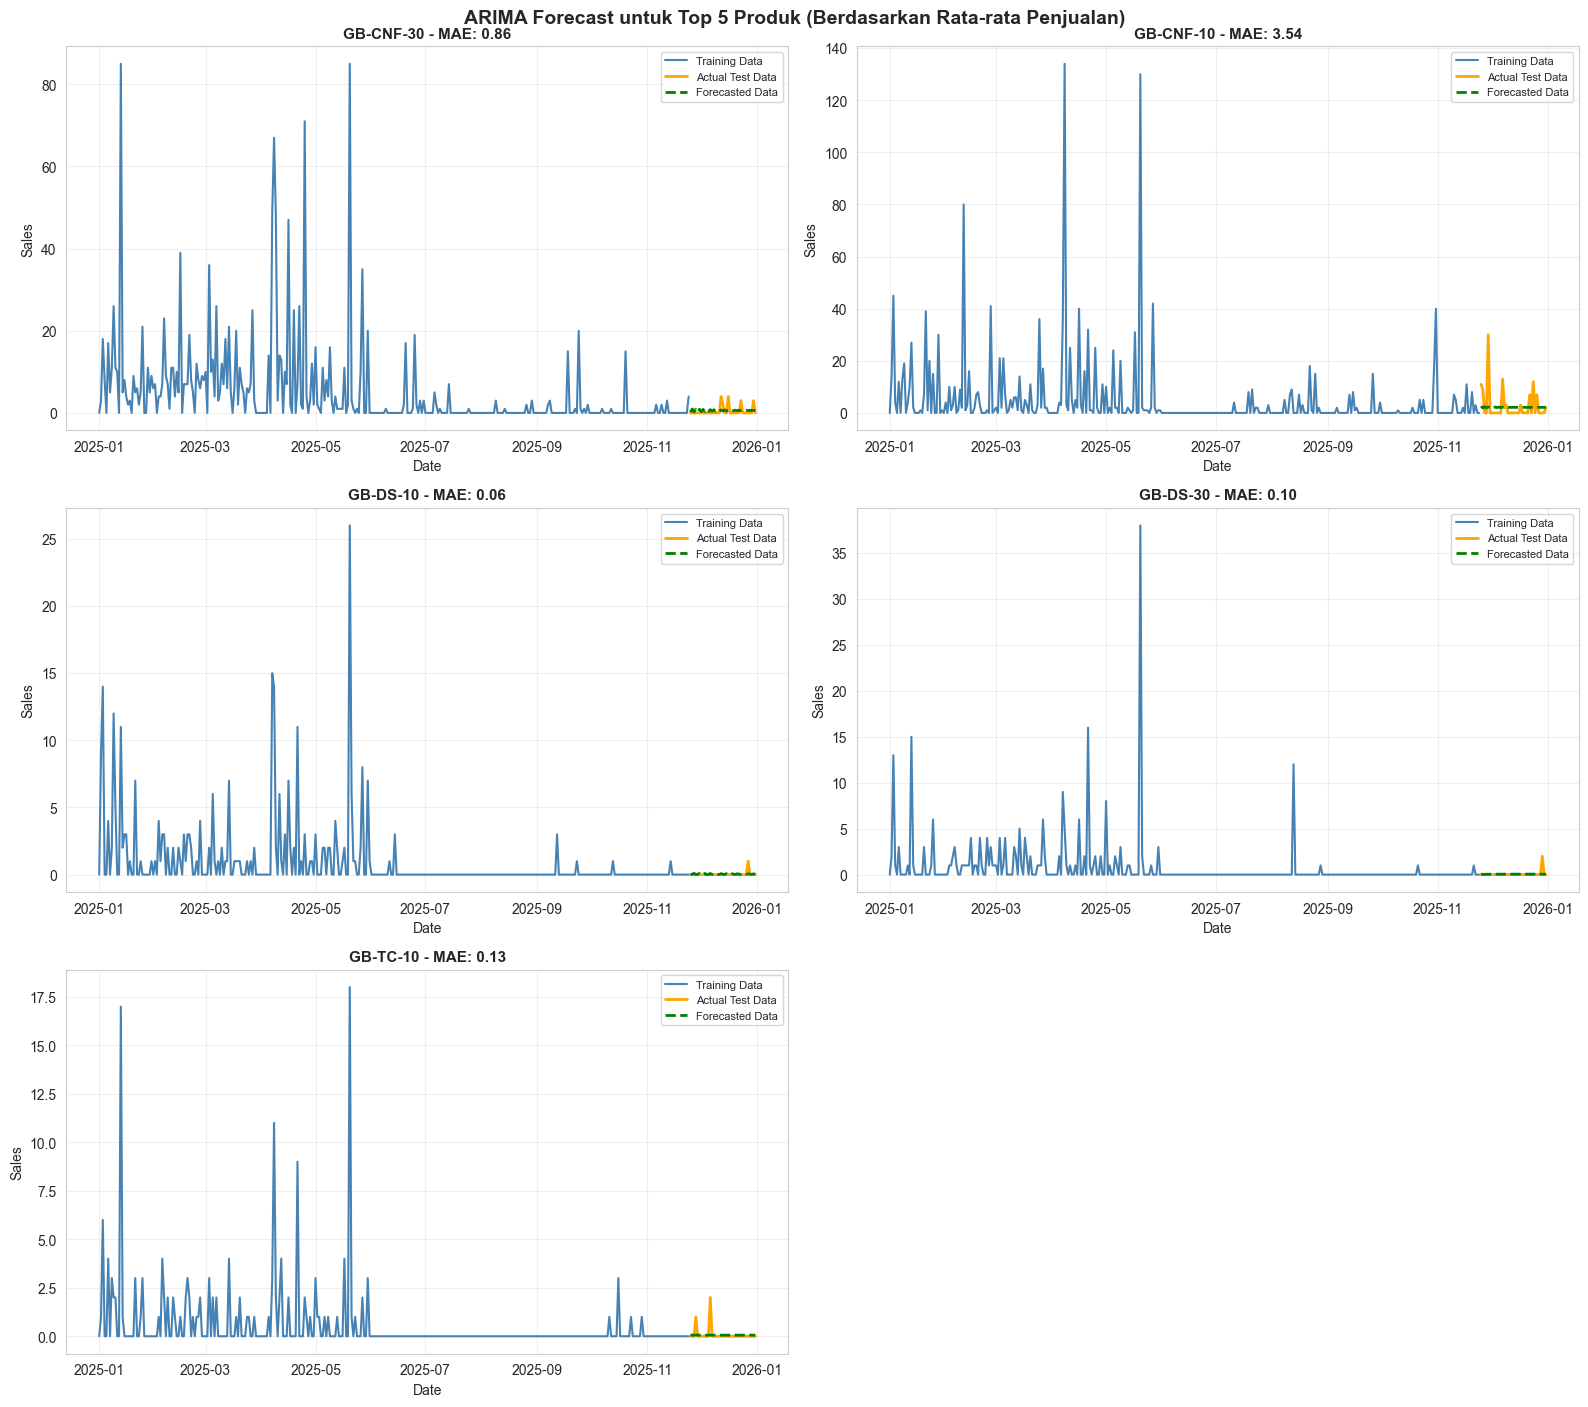

In [9]:

# Visualisasi forecast untuk 5 produk dengan penjualan tertinggi
# Hitung rata-rata penjualan per produk
avg_sales = dataset[product_columns].mean().sort_values(ascending=False)
top_5_products = avg_sales.head(5).index.tolist()

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, product in enumerate(top_5_products):
    if product in forecast_results and forecast_results[product]['success']:
        result = forecast_results[product]
        
        ax = axes[idx]
        
        # Plot training data
        ax.plot(result['train_data'].index, result['train_data'], 
                label='Training Data', color='steelblue', linewidth=1.5)
        
        # Plot test data
        ax.plot(result['test_data'].index, result['test_data'], 
                label='Actual Test Data', color='orange', linewidth=2)
        
        # Plot forecast
        ax.plot(result['test_data'].index, result['forecast'], 
                label='Forecasted Data', linestyle='--', color='green', linewidth=2)
        
        ax.set_title(f'{product} - MAE: {result["mae"]:.2f}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Date')
        ax.set_ylabel('Sales')
        ax.legend(loc='best', fontsize=8)
        ax.grid(True, alpha=0.3)

# Sembunyikan subplot ke-6 yang tidak terpakai
axes[5].set_visible(False)

plt.tight_layout()
plt.suptitle('ARIMA Forecast untuk Top 5 Produk (Berdasarkan Rata-rata Penjualan)', 
             fontsize=14, fontweight='bold', y=1.002)
plt.show()


## 9. Distribusi Error Metrics

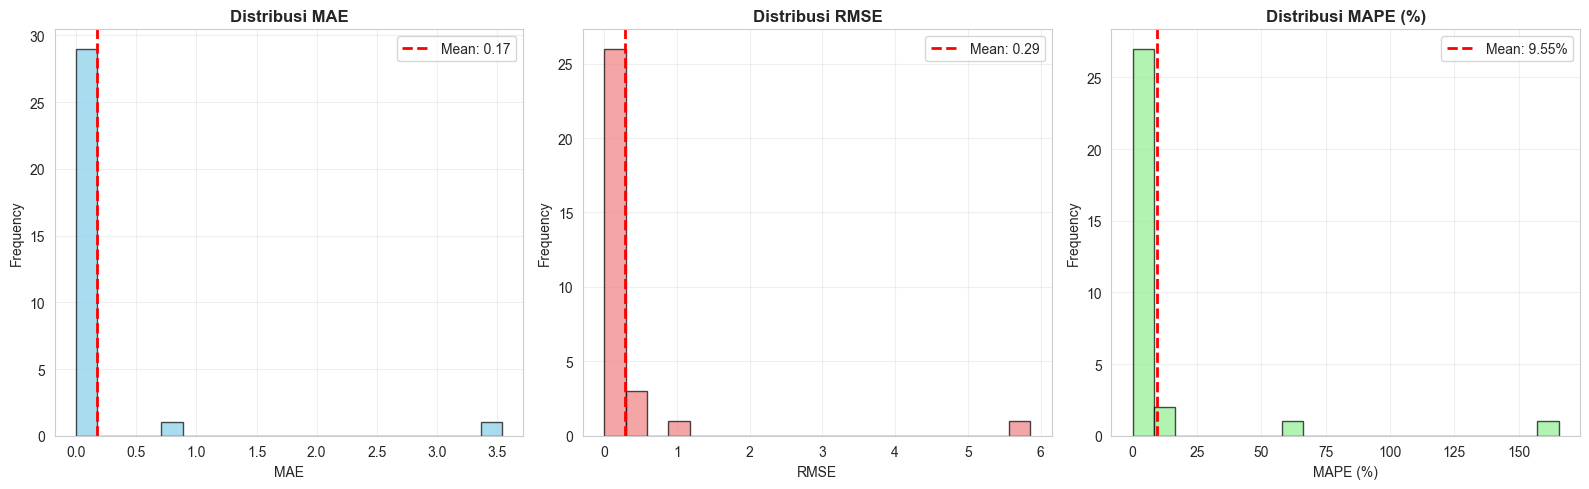

In [ ]:
# Visualisasi distribusi error metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# MAE Distribution
axes[0].hist(summary_df['MAE'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(summary_df['MAE'].mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {summary_df["MAE"].mean():.2f}')
axes[0].set_title('Distribusi MAE', fontsize=12, fontweight='bold')
axes[0].set_xlabel('MAE')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# RMSE Distribution
axes[1].hist(summary_df['RMSE'], bins=20, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1].axvline(summary_df['RMSE'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {summary_df["RMSE"].mean():.2f}')
axes[1].set_title('Distribusi RMSE', fontsize=12, fontweight='bold')
axes[1].set_xlabel('RMSE')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# MAPE Distribution
axes[2].hist(summary_df['MAPE (%)'], bins=20, color='lightgreen', edgecolor='black', alpha=0.7)
axes[2].axvline(summary_df['MAPE (%)'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {summary_df["MAPE (%)"].mean():.2f}%')
axes[2].set_title('Distribusi MAPE (%)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('MAPE (%)')
axes[2].set_ylabel('Frequency')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Export Hasil Forecasting ke CSV

Export hasil forecasting dalam 2 format:
1. **Summary metrics** per produk
2. **Detailed forecast** dengan data aktual vs prediksi

In [ ]:
# 1. Export Summary Metrics per Produk (sudah termasuk Kategori MAE)
summary_export = summary_df.copy()
summary_export = summary_export.sort_values('MAE', ascending=True)

output_file_1 = 'arima_forecast_summary_per_produk.csv'
summary_export.to_csv(output_file_1, index=False, encoding='utf-8-sig')

# 1b. Export tabel ringkas kategori MAE untuk integrasi Laravel
mae_category_summary = (
    summary_df.groupby('Kategori MAE', observed=True)
    .agg(
        jumlah_produk=('Produk', 'count'),
        mae_rata_rata=('MAE', 'mean'),
        rmse_rata_rata=('RMSE', 'mean'),
        mape_rata_rata=('MAPE (%)', 'mean')
    )
    .reset_index()
    .sort_values('Kategori MAE')
)

mae_category_summary['mae_rata_rata'] = mae_category_summary['mae_rata_rata'].round(2)
mae_category_summary['rmse_rata_rata'] = mae_category_summary['rmse_rata_rata'].round(2)
mae_category_summary['mape_rata_rata'] = mae_category_summary['mape_rata_rata'].round(2)

output_file_5 = 'arima_forecast_mae_kategori_ringkas.csv'
mae_category_summary.to_csv(output_file_5, index=False, encoding='utf-8-sig')

print(f"✅ Summary metrics berhasil disimpan ke: {output_file_1}")
print(f"✅ Ringkasan kategori MAE berhasil disimpan ke: {output_file_5}")
print(f"\nPreview (Top 10 produk dengan MAE terendah):")
print(summary_export.head(10).to_string(index=False))

print("\nPreview ringkasan kategori MAE:")
print(mae_category_summary.to_string(index=False))

✅ Summary metrics berhasil disimpan ke: arima_forecast_summary_per_produk.csv
✅ Ringkasan kategori MAE berhasil disimpan ke: arima_forecast_mae_kategori_ringkas.csv

Preview (Top 10 produk dengan MAE terendah):
    Produk ARIMA Order  MAE  RMSE  MAPE (%) Stationary  ADF p-value Kategori MAE
GB-CNF-250   (0, 1, 1)  0.0   0.0      0.23         Ya       0.0000       rendah
GB-CNF-100   (1, 1, 1)  0.0   0.0      0.00         Ya       0.0010       rendah
 GB-DS-250   (1, 1, 1)  0.0   0.0      0.00         Ya       0.0000       rendah
 GB-DS-100   (2, 1, 2)  0.0   0.0      0.00      Tidak       0.1159       rendah
 GB-GF-250   (1, 1, 1)  0.0   0.0      0.04         Ya       0.0000       rendah
GB-LDR-250   (0, 1, 1)  0.0   0.0      0.23         Ya       0.0000       rendah
 GB-JOY-10   (1, 1, 1)  0.0   0.0      0.33         Ya       0.0134       rendah
GB-JOY-100   (1, 1, 1)  0.0   0.0      0.01         Ya       0.0042       rendah
 GB-LDR-30   (0, 1, 1)  0.0   0.0      0.12         Ya      

In [ ]:
# 2. Export Detailed Forecast (Actual vs Predicted) untuk semua produk
detailed_forecast = []

# Mapping kategori MAE per produk agar siap dipakai di Laravel
product_mae_category_map = dict(zip(summary_df['Produk'], summary_df['Kategori MAE'].astype(str)))

for product, result in forecast_results.items():
    if result['success']:
        product_category = product_mae_category_map.get(product, 'unknown')
        for date, actual, predicted in zip(result['test_data'].index, 
                                           result['test_data'].values, 
                                           result['forecast'].values):
            detailed_forecast.append({
                'Date': date,
                'Produk': product,
                'Kategori_MAE': product_category,
                'Actual_Sales': round(actual, 2),
                'Predicted_Sales': round(predicted, 2),
                'Error': round(actual - predicted, 2),
                'Absolute_Error': round(abs(actual - predicted), 2)
            })

detailed_df = pd.DataFrame(detailed_forecast)

output_file_2 = 'arima_forecast_detailed_per_produk.csv'
detailed_df.to_csv(output_file_2, index=False, encoding='utf-8-sig')

print(f"\n✅ Detailed forecast berhasil disimpan ke: {output_file_2}")
print(f"\nTotal records: {len(detailed_df)}")
print(f"\nPreview 10 baris pertama:")
print(detailed_df.head(10).to_string(index=False))


✅ Detailed forecast berhasil disimpan ke: arima_forecast_detailed_per_produk.csv

Total records: 1147

Preview 10 baris pertama:
      Date   Produk Kategori_MAE  Actual_Sales  Predicted_Sales  Error  Absolute_Error
2025-11-25 GB-BB-10       tinggi           0.0             0.12  -0.12            0.12
2025-11-26 GB-BB-10       tinggi           0.0             0.11  -0.11            0.11
2025-11-27 GB-BB-10       tinggi           0.0             0.11  -0.11            0.11
2025-11-28 GB-BB-10       tinggi           0.0             0.10  -0.10            0.10
2025-11-29 GB-BB-10       tinggi           0.0             0.11  -0.11            0.11
2025-11-30 GB-BB-10       tinggi           0.0             0.10  -0.10            0.10
2025-12-01 GB-BB-10       tinggi           0.0             0.11  -0.11            0.11
2025-12-02 GB-BB-10       tinggi           0.0             0.10  -0.10            0.10
2025-12-03 GB-BB-10       tinggi           0.0             0.11  -0.11            0.11


## 11. Perbandingan Forecast dengan Aktual (Pivot Table)

In [ ]:
# Buat pivot table untuk perbandingan actual vs predicted
pivot_actual = detailed_df.pivot_table(
    index='Date', 
    columns='Produk', 
    values='Actual_Sales'
)

pivot_predicted = detailed_df.pivot_table(
    index='Date', 
    columns='Produk', 
    values='Predicted_Sales'
)

# Export pivot tables
output_file_3 = 'arima_forecast_actual_pivot.csv'
output_file_4 = 'arima_forecast_predicted_pivot.csv'

pivot_actual.to_csv(output_file_3, encoding='utf-8-sig')
pivot_predicted.to_csv(output_file_4, encoding='utf-8-sig')

print(f"✅ Pivot table (Actual) disimpan ke: {output_file_3}")
print(f"✅ Pivot table (Predicted) disimpan ke: {output_file_4}")

print(f"\nPreview Actual Sales (5 produk pertama, 5 tanggal pertama):")
print(pivot_actual.iloc[:5, :5])

print(f"\nPreview Predicted Sales (5 produk pertama, 5 tanggal pertama):")
print(pivot_predicted.iloc[:5, :5])

✅ Pivot table (Actual) disimpan ke: arima_forecast_actual_pivot.csv
✅ Pivot table (Predicted) disimpan ke: arima_forecast_predicted_pivot.csv

Preview Actual Sales (5 produk pertama, 5 tanggal pertama):
Produk      GB-BB-10  GB-BB-30  GB-CNF-10  GB-CNF-100  GB-CNF-250
Date                                                             
2025-11-25       0.0       0.0       11.0         0.0         0.0
2025-11-26       0.0       0.0        9.0         0.0         0.0
2025-11-27       0.0       0.0        0.0         0.0         0.0
2025-11-28       0.0       0.0        0.0         0.0         0.0
2025-11-29       0.0       0.0       30.0         0.0         0.0

Preview Predicted Sales (5 produk pertama, 5 tanggal pertama):
Produk      GB-BB-10  GB-BB-30  GB-CNF-10  GB-CNF-100  GB-CNF-250
Date                                                             
2025-11-25      0.12      0.04       2.53         0.0         0.0
2025-11-26      0.11      0.04       1.94         0.0         0.0
2025-11

## 12. Kesimpulan dan Rekomendasi

In [ ]:
print("\n" + "=" * 90)
print("KESIMPULAN DAN REKOMENDASI")
print("=" * 90)

# Hitung berapa produk yang berhasil di-forecast
successful_forecasts = sum(1 for r in forecast_results.values() if r['success'])

print(f"\n📊 HASIL FORECASTING:")
print(f"   • Total produk dianalisis: {len(product_columns)}")
print(f"   • Produk berhasil di-forecast: {successful_forecasts}")
print(f"   • Average MAE: {summary_df['MAE'].mean():.2f}")
print(f"   • Average RMSE: {summary_df['RMSE'].mean():.2f}")
print(f"   • Average MAPE: {summary_df['MAPE (%)'].mean():.2f}%")

if not summary_df.empty and 'Kategori MAE' in summary_df.columns:
    print("\n📌 DISTRIBUSI KATEGORI MAE:")
    cat_count = summary_df['Kategori MAE'].value_counts().sort_index()
    for cat_name, cat_total in cat_count.items():
        print(f"   • {cat_name}: {cat_total} produk")

print(f"\n🏆 PRODUK DENGAN PREDIKSI TERBAIK (Top 5):")
for idx, row in summary_df.nsmallest(5, 'MAE').iterrows():
    print(f"   {idx+1}. {row['Produk']}: MAE = {row['MAE']:.2f} | Order = {row['ARIMA Order']}")

print(f"\n⚠️  PRODUK YANG PERLU TUNING MODEL (Top 5):")
for idx, row in summary_df.nlargest(5, 'MAE').iterrows():
    print(f"   {idx+1}. {row['Produk']}: MAE = {row['MAE']:.2f} | Order = {row['ARIMA Order']}")

# Ringkasan distribusi order terpilih
order_distribution = summary_df['ARIMA Order'].value_counts().head(5)
print(f"\n🔎 ORDER ARIMA YANG PALING SERING TERPILIH (Top 5):")
for order_name, count in order_distribution.items():
    print(f"   • {order_name}: {count} produk")

print(f"\n💡 REKOMENDASI:")
print("   1. Produk dengan MAE rendah gunakan model paling sederhana yang performanya tetap baik (parsimonious)")
print("   2. Produk dengan MAE menengah/tinggi lakukan retuning dengan kandidat ARIMA yang lebih luas")
print("   3. Prioritaskan monitoring untuk produk dengan MAE tertinggi")
print("   4. Pertimbangkan SARIMA/fitur eksternal bila pola musiman atau lonjakan sulit ditangkap")

print("=" * 90)

# Export file list
print(f"\n📁 FILE YANG DIHASILKAN:")
print(f"   1. {output_file_1} - Summary metrics per produk")
print(f"   2. {output_file_2} - Detail forecast actual vs predicted")
print(f"   3. {output_file_3} - Pivot table actual sales")
print(f"   4. {output_file_4} - Pivot table predicted sales")
print(f"   5. {output_file_5} - Ringkasan kategori MAE (rendah/menengah/tinggi)")
print("=" * 90)


KESIMPULAN DAN REKOMENDASI

📊 HASIL FORECASTING:
   • Total produk dianalisis: 31
   • Produk berhasil di-forecast: 31
   • Average MAE: 0.17
   • Average RMSE: 0.29
   • Average MAPE: 9.55%

📌 DISTRIBUSI KATEGORI MAE:
   • rendah: 12 produk
   • menengah: 10 produk
   • tinggi: 9 produk

🏆 PRODUK DENGAN PREDIKSI TERBAIK (Top 5):
   6. GB-CNF-100: MAE = 0.00 | Order = (1, 1, 1)
   7. GB-CNF-250: MAE = 0.00 | Order = (0, 1, 1)
   10. GB-DS-100: MAE = 0.00 | Order = (2, 1, 2)
   11. GB-DS-250: MAE = 0.00 | Order = (1, 1, 1)
   14. GB-GF-250: MAE = 0.00 | Order = (1, 1, 1)

⚠️  PRODUK YANG PERLU TUNING MODEL (Top 5):
   5. GB-CNF-10: MAE = 3.54 | Order = (3, 1, 2)
   4. GB-CNF-30: MAE = 0.86 | Order = (3, 1, 2)
   1. GB-BB-10: MAE = 0.13 | Order = (3, 1, 3)
   29. GB-TC-10: MAE = 0.13 | Order = (3, 1, 2)
   8. GB-DS-30: MAE = 0.10 | Order = (2, 1, 3)

🔎 ORDER ARIMA YANG PALING SERING TERPILIH (Top 5):
   • (1, 1, 1): 8 produk
   • (0, 1, 1): 8 produk
   • (3, 1, 2): 7 produk
   • (2, 1, 

## 13. Forecasting 1 Tahun ke Depan

Menggunakan model ARIMA yang sudah terlatih untuk melakukan forecasting 365 hari ke depan untuk semua produk.

In [ ]:
# Fungsi untuk forecast 1 tahun ke depan menggunakan model terbaik
def forecast_one_year(product_name, full_data, trained_result, forecast_days=365):
    """
    Melakukan forecast 1 tahun ke depan menggunakan seluruh data historis
    untuk re-fit model dengan order terbaik yang sudah ditentukan
    """
    try:
        # Re-fit model dengan SELURUH data (bukan hanya training set)
        # menggunakan order terbaik yang sudah ditentukan
        best_order = trained_result.get('used_order', (2, 1, 2))
        
        # Pastikan data lengkap
        complete_date_range = pd.date_range(start=full_data.index.min(), end=full_data.index.max(), freq='D')
        data_reindexed = full_data.reindex(complete_date_range).ffill().fillna(0)
        
        # Fit model dengan seluruh data
        model = ARIMA(data_reindexed, order=best_order)
        fitted_model = model.fit()
        
        # Forecast 1 tahun ke depan
        forecast_1year = fitted_model.forecast(steps=forecast_days)
        forecast_1year = np.maximum(forecast_1year, 0)  # Hindari nilai negatif
        
        # Buat date index untuk forecast
        last_date = data_reindexed.index[-1]
        forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_days, freq='D')
        
        return {
            'product': product_name,
            'success': True,
            'last_historical_date': last_date,
            'forecast_dates': forecast_dates,
            'forecast_values': forecast_1year,
            'full_data': data_reindexed,
            'order': best_order,
            'fitted_model': fitted_model
        }
    except Exception as e:
        print(f"Error forecasting 1 year for {product_name}: {str(e)}")
        return {
            'product': product_name,
            'success': False,
            'error': str(e)
        }

# Generate 1-year forecast untuk semua produk
print("Generating 1-year forecast untuk semua produk...")
print("=" * 90)

forecast_1year_results = {}

for i, product in enumerate(product_columns, 1):
    if product in forecast_results and forecast_results[product]['success']:
        print(f"[{i}/{len(product_columns)}] {product}...", end=" ")
        
        result = forecast_one_year(
            product_name=product,
            full_data=dataset[product],
            trained_result=forecast_results[product],
            forecast_days=365
        )
        
        forecast_1year_results[product] = result
        
        if result['success']:
            print("✅")
        else:
            print("❌")

print("=" * 90)
print(f"✅ 1-year forecast berhasil untuk {sum(1 for r in forecast_1year_results.values() if r.get('success'))} produk!")


## 14. Visualisasi Forecast 1 Tahun untuk Top 5 Produk

In [ ]:
# Visualisasi 1-year forecast untuk 5 produk dengan penjualan tertinggi
fig, axes = plt.subplots(3, 2, figsize=(18, 14))
axes = axes.flatten()

for idx, product in enumerate(top_5_products):
    if product in forecast_1year_results and forecast_1year_results[product]['success']:
        result = forecast_1year_results[product]
        
        ax = axes[idx]
        
        # Plot historical data (last 2 years untuk clarity)
        last_2_years = result['full_data'].iloc[-730:] if len(result['full_data']) > 730 else result['full_data']
        ax.plot(last_2_years.index, last_2_years.values, 
                label='Data Historis (2 tahun terakhir)', color='steelblue', linewidth=2)
        
        # Plot 1-year forecast
        ax.plot(result['forecast_dates'], result['forecast_values'], 
                label='Forecast 1 Tahun', linestyle='--', color='red', linewidth=2.5)
        
        # Highlight forecast region
        ax.axvspan(result['forecast_dates'][0], result['forecast_dates'][-1], 
                   alpha=0.15, color='red', label='Periode Forecast')
        
        # Format
        ax.set_title(f'{product}\n(Order ARIMA: {result["order"]})', 
                    fontsize=12, fontweight='bold')
        ax.set_xlabel('Date', fontsize=10)
        ax.set_ylabel('Sales', fontsize=10)
        ax.legend(loc='best', fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45)

# Sembunyikan subplot ke-6
axes[5].set_visible(False)

plt.suptitle('ARIMA Forecast 1 Tahun ke Depan - Top 5 Produk (Berdasarkan Rata-rata Penjualan)', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("✅ Visualisasi forecast 1 tahun selesai!")


## 15. Visualisasi Detail Forecast 1 Tahun dengan Monthly Aggregation

In [ ]:
# Visualisasi dengan aggregasi bulanan (monthly) untuk clarity lebih baik
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

top_6_products = avg_sales.head(6).index.tolist()

for idx, product in enumerate(top_6_products):
    if product in forecast_1year_results and forecast_1year_results[product]['success']:
        result = forecast_1year_results[product]
        
        ax = axes[idx]
        
        # Monthly aggregation untuk data historis (last 2 years)
        full_data = result['full_data']
        last_2_years = full_data.iloc[-730:] if len(full_data) > 730 else full_data
        
        # Create DataFrame untuk historical data
        hist_df = pd.DataFrame({
            'date': last_2_years.index,
            'sales': last_2_years.values
        })
        hist_df['year_month'] = hist_df['date'].dt.to_period('M')
        hist_monthly = hist_df.groupby('year_month')['sales'].sum()
        hist_monthly.index = hist_monthly.index.to_timestamp()
        
        # Monthly aggregation untuk forecast
        forecast_df = pd.DataFrame({
            'date': result['forecast_dates'],
            'sales': result['forecast_values']
        })
        forecast_df['year_month'] = forecast_df['date'].dt.to_period('M')
        forecast_monthly = forecast_df.groupby('year_month')['sales'].sum()
        forecast_monthly.index = forecast_monthly.index.to_timestamp()
        
        # Plot
        ax.bar(hist_monthly.index, hist_monthly.values, width=20, 
               label='Data Historis (Monthly)', color='steelblue', alpha=0.7)
        ax.bar(forecast_monthly.index, forecast_monthly.values, width=20, 
               label='Forecast 1 Tahun (Monthly)', color='red', alpha=0.7)
        
        # Vertical line untuk pemisah
        ax.axvline(x=last_2_years.index[-1], color='black', linestyle='--', linewidth=1.5, alpha=0.5)
        
        # Format
        ax.set_title(f'{product}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Bulan', fontsize=9)
        ax.set_ylabel('Total Penjualan', fontsize=9)
        ax.legend(loc='best', fontsize=8)
        ax.grid(True, alpha=0.3, axis='y')
        ax.tick_params(axis='x', rotation=45, labelsize=8)

plt.suptitle('Monthly Aggregation: Data Historis vs Forecast 1 Tahun - Top 6 Produk', 
             fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("✅ Visualisasi monthly aggregation selesai!")


## 16. Export Forecast 1 Tahun ke CSV

In [ ]:
# Export 1-year forecast ke berbagai format

# 1. Format detail (harian) - Daily forecast
print("Exporting 1-year forecast data...")
print("=" * 90)

forecast_1year_daily = []

for product, result in forecast_1year_results.items():
    if result['success']:
        product_category = product_mae_category_map.get(product, 'unknown')
        mae = summary_df[summary_df['Produk'] == product]['MAE'].values[0] if product in summary_df['Produk'].values else 0
        
        for date, forecast_val in zip(result['forecast_dates'], result['forecast_values']):
            forecast_1year_daily.append({
                'Date': date,
                'Produk': product,
                'Kategori_MAE': product_category,
                'Forecast_Sales': round(forecast_val, 2),
                'MAE_Model': round(mae, 2),
                'ARIMA_Order': str(result['order'])
            })

forecast_1year_daily_df = pd.DataFrame(forecast_1year_daily)

output_1year_daily = 'arima_forecast_1tahun_harian.csv'
forecast_1year_daily_df.to_csv(output_1year_daily, index=False, encoding='utf-8-sig')

print(f"✅ {output_1year_daily} ({len(forecast_1year_daily_df)} rows)")
print(f"   Preview:")
print(forecast_1year_daily_df.head(10).to_string(index=False))

# 2. Format pivot - Daily pivot table
print("\n" + "=" * 90)

pivot_1year = forecast_1year_daily_df.pivot_table(
    index='Date',
    columns='Produk',
    values='Forecast_Sales'
)

output_1year_pivot = 'arima_forecast_1tahun_pivot.csv'
pivot_1year.to_csv(output_1year_pivot, encoding='utf-8-sig')

print(f"✅ {output_1year_pivot}")
print(f"   Preview (5 produk pertama, 5 tanggal pertama):")
print(pivot_1year.iloc[:5, :5])

# 3. Format bulanan (monthly aggregation) - Monthly summary
print("\n" + "=" * 90)

forecast_1year_monthly = []

for product, result in forecast_1year_results.items():
    if result['success']:
        product_category = product_mae_category_map.get(product, 'unknown')
        
        # Monthly aggregation
        forecast_df_temp = pd.DataFrame({
            'date': result['forecast_dates'],
            'sales': result['forecast_values']
        })
        forecast_df_temp['year_month'] = forecast_df_temp['date'].dt.to_period('M')
        monthly_agg = forecast_df_temp.groupby('year_month')['sales'].agg(['sum', 'mean', 'min', 'max']).reset_index()
        
        for _, row in monthly_agg.iterrows():
            forecast_1year_monthly.append({
                'Year_Month': str(row['year_month']),
                'Produk': product,
                'Kategori_MAE': product_category,
                'Total_Forecast': round(row['sum'], 2),
                'Avg_Daily_Forecast': round(row['mean'], 2),
                'Min_Daily_Forecast': round(row['min'], 2),
                'Max_Daily_Forecast': round(row['max'], 2)
            })

forecast_1year_monthly_df = pd.DataFrame(forecast_1year_monthly)

output_1year_monthly = 'arima_forecast_1tahun_bulanan.csv'
forecast_1year_monthly_df.to_csv(output_1year_monthly, index=False, encoding='utf-8-sig')

print(f"✅ {output_1year_monthly} ({len(forecast_1year_monthly_df)} rows)")
print(f"   Preview:")
print(forecast_1year_monthly_df.head(12).to_string(index=False))

print("\n" + "=" * 90)
print(f"📁 EXPORT SELESAI - File yang dihasilkan:")
print(f"   1. {output_1year_daily} - Forecast harian (365 hari x semua produk)")
print(f"   2. {output_1year_pivot} - Pivot table forecast harian")
print(f"   3. {output_1year_monthly} - Forecast bulanan dengan statistik (sum, avg, min, max)")
print("=" * 90)


## 17. Ringkasan Forecast & Insights 1 Tahun ke Depan

In [ ]:
# Ringkasan 1-year forecast
print("\n" + "=" * 90)
print("RINGKASAN FORECAST 1 TAHUN KE DEPAN")
print("=" * 90)

successful_1year = sum(1 for r in forecast_1year_results.values() if r.get('success'))

print(f"\n📊 STATISTIK FORECAST 1 TAHUN:")
print(f"   • Produk dengan forecast 1 tahun: {successful_1year}/{len(product_columns)}")
print(f"   • Total baris forecast (harian): {len(forecast_1year_daily_df)}")
print(f"   • Periode forecast: {forecast_1year_daily_df['Date'].min().date()} s/d {forecast_1year_daily_df['Date'].max().date()}")
print(f"   • Total hari yang diprediksi: {(forecast_1year_daily_df['Date'].max() - forecast_1year_daily_df['Date'].min()).days + 1} hari")

# Analisis forecast total per kategori MAE
print(f"\n💼 FORECAST TOTAL PER KATEGORI MAE (1 TAHUN):")
forecast_by_category = forecast_1year_daily_df.groupby('Kategori_MAE')['Forecast_Sales'].sum().sort_index()
for cat, total in forecast_by_category.items():
    pct = (total / forecast_1year_daily_df['Forecast_Sales'].sum()) * 100
    print(f"   • {cat}: {total:,.0f} units ({pct:.1f}%)")

print(f"\n   • TOTAL SELURUH PRODUK: {forecast_1year_daily_df['Forecast_Sales'].sum():,.0f} units")

# Top 5 produk dengan forecast terbesar
print(f"\n🏆 TOP 5 PRODUK DENGAN FORECAST PENJUALAN TERTINGGI (1 TAHUN):")
top_5_forecast = forecast_1year_daily_df.groupby('Produk')['Forecast_Sales'].sum().nlargest(5)
for i, (product, total) in enumerate(top_5_forecast.items(), 1):
    mae = summary_df[summary_df['Produk'] == product]['MAE'].values[0] if product in summary_df['Produk'].values else 0
    print(f"   {i}. {product}: {total:,.0f} units (MAE: {mae:.2f})")

# Monthly trend
print(f"\n📈 TREND FORECAST BULANAN (Top 3 Produk):")
top_3_monthly = forecast_1year_monthly_df[forecast_1year_monthly_df['Produk'].isin(top_5_forecast.index.tolist()[:3])]
for product in top_3_monthly['Produk'].unique():
    product_monthly = top_3_monthly[top_3_monthly['Produk'] == product]
    avg_monthly = product_monthly['Total_Forecast'].mean()
    min_monthly = product_monthly['Total_Forecast'].min()
    max_monthly = product_monthly['Total_Forecast'].max()
    print(f"   • {product}:")
    print(f"     - Rata-rata bulanan: {avg_monthly:,.0f} units")
    print(f"     - Min (bulan terrendah): {min_monthly:,.0f} units")
    print(f"     - Max (bulan tertinggi): {max_monthly:,.0f} units")

# Rekomendasi
print(f"\n💡 REKOMENDASI BERDASARKAN FORECAST 1 TAHUN:")
print("   1. Produk dengan forecast tinggi → prioritas produksi dan inventori")
print("   2. Produk dengan MAE rendah dan forecast tinggi → sangat reliable untuk planning")
print("   3. Produk dengan MAE tinggi → tambahkan buffer stock lebih besar")
print("   4. Monitor setiap bulan dan lakukan reforecast jika ada perubahan signifikan")
print("   5. Gunakan forecast bulanan untuk perencanaan procurement & produksi")

print("\n" + "=" * 90)
